In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
!pip install lightgbm
import lightgbm as lgb
import numpy as np

In [2]:
df = pd.read_csv('global_fuel_prices_2020_2026.csv')

In [3]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [4]:
df.tail()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.0,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.0,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.0,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.0,43.7
27467,2026-04-06,Rwanda,Africa,Low,Low,3.064,2.846,2.296,130.0,63.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [6]:
df.describe()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2.281915,2.133760,1.711473,106.686453,26.774468
std,1.540612,1.465058,1.155543,18.972391,17.203349
min,0.010000,0.010000,0.010000,47.970000,0.000000
25%,0.926000,0.858000,0.695000,101.140000,13.500000
50%,2.116500,1.954500,1.588000,112.270000,23.400000
75%,3.457000,3.231000,2.590000,119.410000,38.900000
max,6.779000,6.240000,5.100000,130.000000,65.000000


In [7]:
df.isnull().sum()

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
dtype: int64

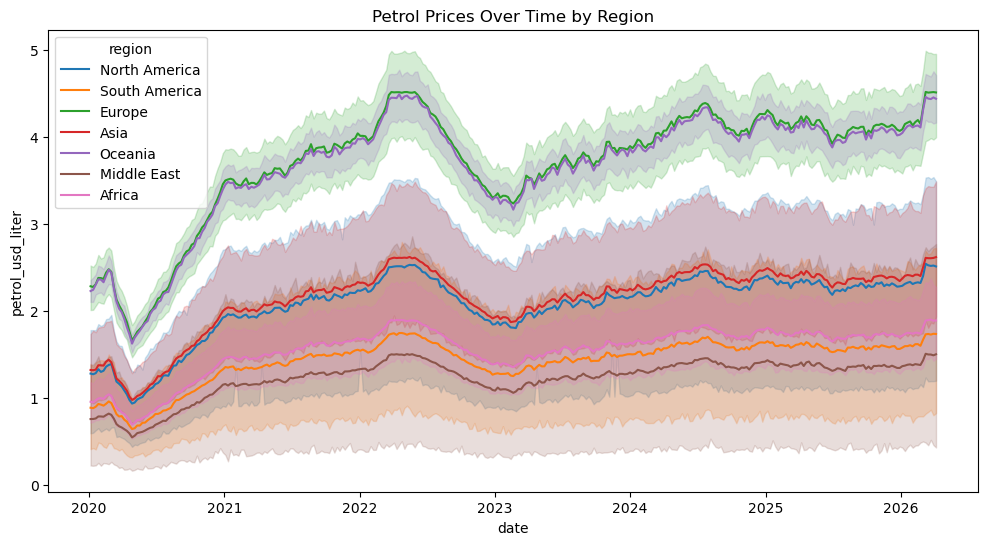

In [8]:
df['date'] = pd.to_datetime(df['date'])
plt.figure(figsize=(12,6))
sns.lineplot(data=df,x="date",y="petrol_usd_liter",hue="region")
plt.title("Petrol Prices Over Time by Region")
plt.show()

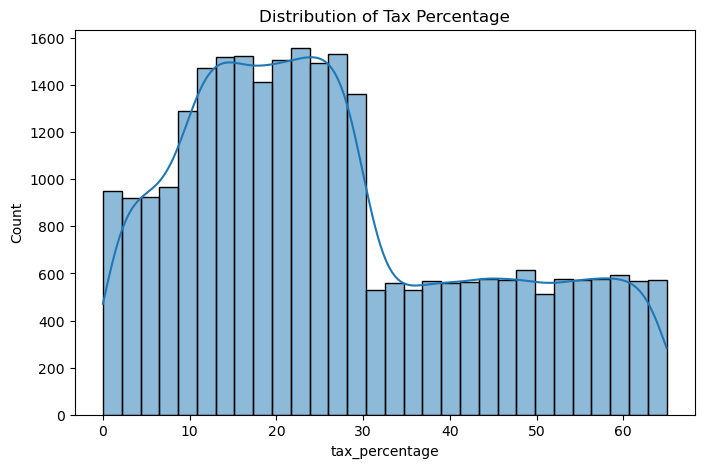

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['tax_percentage'],bins=30,kde=True)
plt.title("Distribution of Tax Percentage")
plt.show()

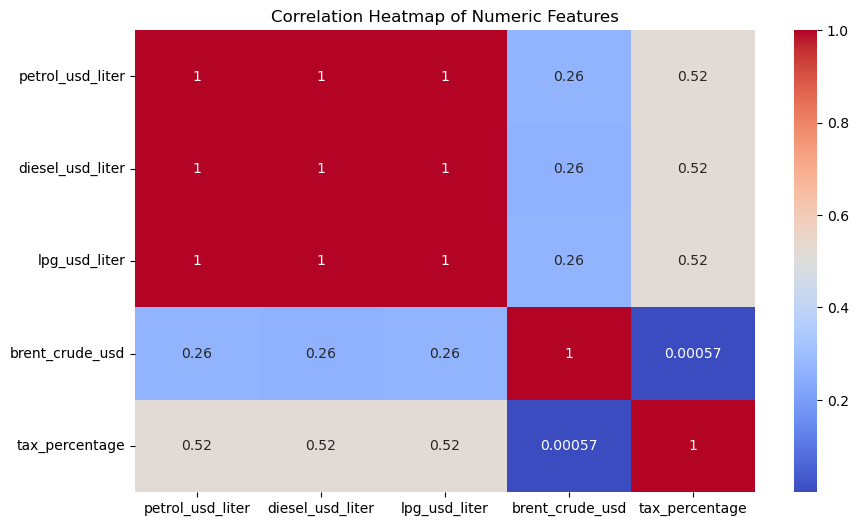

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='float').corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [14]:
cat_cols = ["country","region","income_level","subsidy_level"]
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [15]:
X = df.drop(["date","petrol_usd_liter"],axis=1)
y = df["petrol_usd_liter"]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
model = RandomForestRegressor(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1)

In [21]:
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

RMSE: 0.018133521363422212


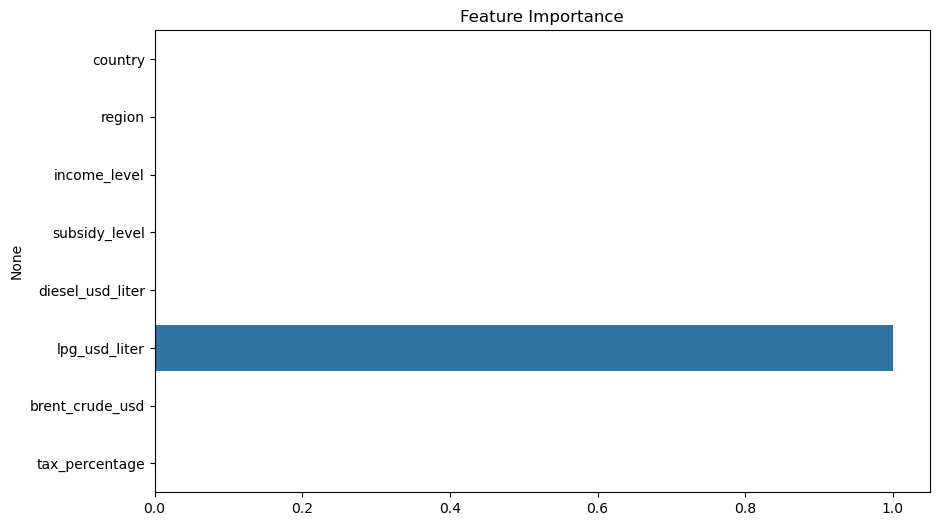

In [24]:
importances = model.feature_importances_
feat_names = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.show()